# ML Model Evaluation Exercise

### Group / Home Work
#### Evaluate seleced model performance on cancer data

- load breast cancer classification dataset
- select two classification models and train them using CV approach and compare their results
- for one of the above models perform a grid seach of hyperparameters - hint - check the paramaters on sklearn website
- for the best performing model (using best parameters) report:
  - individual performance metrics (use classification report)
  - print or plot confusion matrix
  - plot ROC and report AUC





In [38]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# add packages according your need
# i.e
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

df=load_breast_cancer()
df_cancer= pd.DataFrame(data= np.c_[df["data"], df['target']],columns= list(df['feature_names']) + ['target'])
df_cancer


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,0.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,0.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,0.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,0.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0.0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0.0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0.0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0.0


In [39]:
X_train, X_test, y_train, y_test = train_test_split(df_cancer[df_cancer.columns[:-1]], df_cancer.target, test_size=0.2, random_state=42)

In [40]:
sc = StandardScaler()
x_train = sc.fit_transform(X_train)
x_test = sc.transform(X_test)

model1 = LogisticRegression()
model2 = SVC(C=100,gamma=100)

model1.fit(x_train,y_train)
y1= model1.predict(x_test)

model2.fit(x_train,y_train)
y2= model1.predict(x_test)


print(model1.score(x_test,y_test))
print(model2.score(x_test,y_test)) #svc chosen one

0.9736842105263158
0.6228070175438597


In [43]:
pipeline = Pipeline([('transformer', sc), ('estimator', SVC())])

param_grid = {
    'estimator__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'estimator__gamma': [0.001, 0.01, 0.1, 1, 10, 100]
    }

grid_search1 = GridSearchCV(pipeline, param_grid, cv=10) # search using pipeline

grid_search1.fit(x_train, y_train)
print("Best parameters - with pipeline: {}".format(grid_search1.best_params_))
print("Best cross-validation score - with pipeline: {:.2f}".format(grid_search1.best_score_))

# using only test set to evaluate
test_score1 = grid_search1.score(x_test, y_test)
print("Test set score with best parameters - with pipeline: {:.2f}".format(test_score1))

Best parameters - with pipeline: {'estimator__C': 100, 'estimator__gamma': 0.001}
Best cross-validation score - with pipeline: 0.97
Test set score with best parameters - with pipeline: 0.98


In [45]:
#Best model & parameter
sc = StandardScaler()
x_train = sc.fit_transform(X_train)
x_test = sc.transform(X_test)
model2 = SVC(C=100,gamma=0.001)
model2.fit(x_train,y_train)
y2= model1.predict(x_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y2))

              precision    recall  f1-score   support

         0.0       0.98      0.95      0.96        43
         1.0       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion matrix:
[[41  2]
 [ 1 70]]


<Axes: >

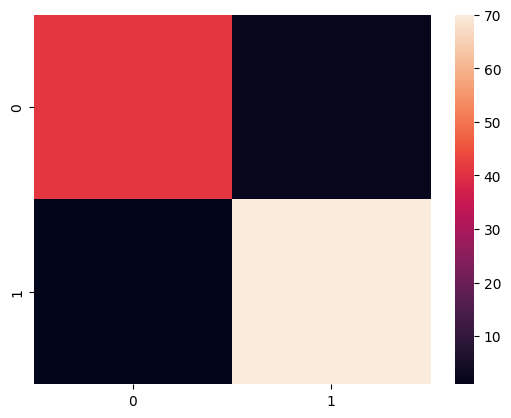

In [46]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, y2)
print("Confusion matrix:\n{}".format(confusion))
sns.heatmap(confusion)

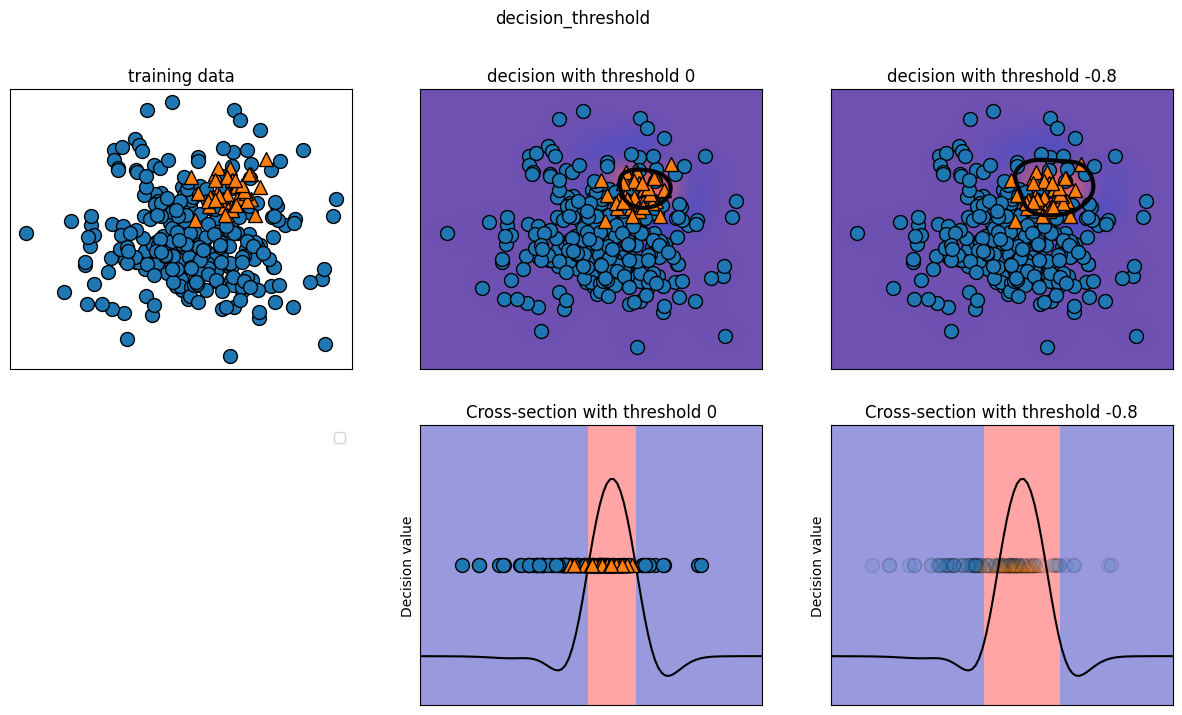

In [47]:
import mglearn
mglearn.plots.plot_decision_threshold()

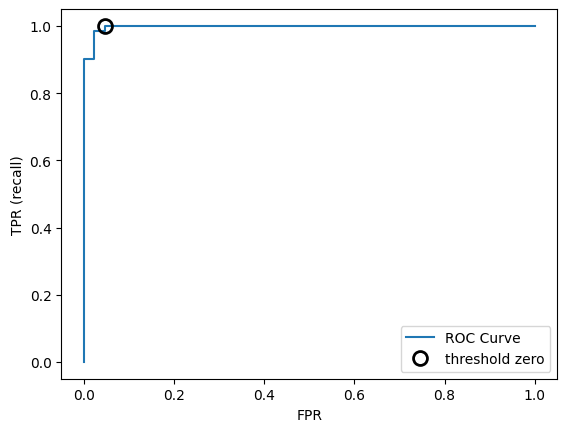

In [49]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, model2.decision_function(x_test))
plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR (recall)")
# find threshold closest to zero
close_zero = np.argmin(np.abs(thresholds))
plt.plot(fpr[close_zero], tpr[close_zero], 'o', markersize=10,
label="threshold zero", fillstyle="none", c='k', mew=2)
plt.legend(loc=4)


In [50]:
from sklearn.metrics import roc_auc_score
svc_auc = roc_auc_score(y_test, model2.decision_function(x_test))
print("AUC for SVC: {:.3f}".format(svc_auc))

AUC for SVC: 0.997
